# Lab Problem Statement 6: Statistical Analysis of Physical Characteristics of Palmer Penguins

**Objective:** Perform descriptive statistics, hypothesis testing, effect-size estimation, one-way ANOVA, Tukey HSD, Kruskal-Wallis test, two-way ANOVA, and flipper-length analysis on the Palmer Penguins dataset.

**Software:** R in Google Colab

**Dataset:** Palmer Penguins dataset with 344 observations and three species: Adélie, Chinstrap, and Gentoo.


## 1. Setup

The following cell installs and loads the R packages required for the complete analysis.

In [ ]:
# Install required packages.
install.packages(c("tidyverse", "palmerpenguins", "moments", "effectsize"), repos = "https://cloud.r-project.org")

library(tidyverse)
library(palmerpenguins)
library(moments)
library(car)
library(effectsize)

options(scipen = 999)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘performance’


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [ ]:
install.packages("car", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘pbkrtest’, ‘lme4’




## 2. Load and Inspect the Dataset

The `palmerpenguins` package provides the Palmer Penguins dataset used for this analysis.

In [ ]:
# Load the penguins dataset.
data("penguins")

head(penguins)
dim(penguins)
str(penguins)
summary(penguins)


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


[1] 344   8

tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

### Data Cleaning

Only observations with non-missing values in the variables required for the analysis are retained.

In [ ]:
# Keep complete observations for the required variables.
penguins_clean <- penguins %>%
  select(species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex) %>%
  drop_na()

penguins_clean <- penguins_clean %>%
  mutate(
    species = factor(species),
    sex = factor(sex)
  )

dim(penguins_clean)


[1] 333   7

## 3. Descriptive Statistical Analysis

The primary variable is **body mass (`body_mass_g`)**. The analysis calculates mean, median, minimum, maximum, variance, standard deviation, quartiles, IQR, skewness, and kurtosis for the complete dataset and separately for each species.

In [ ]:
# Calculate descriptive statistics.
overall_stats <- penguins_clean %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

overall_stats


Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225,0.4701162,2.259514


In [ ]:
# Calculate species-wise descriptive statistics.
species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g),
    .groups = "drop"
  )

species_stats


species,N,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,146,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,68,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,119,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


### Interpretation

The species-wise summary allows comparison of central tendency and variability in body mass. Differences in means and medians indicate variation in typical body mass, while standard deviation and IQR describe within-species spread.

## 4. Visualizations of Body Mass

The required visualizations are a histogram, species-wise boxplot, density plot, and sex-wise boxplot.

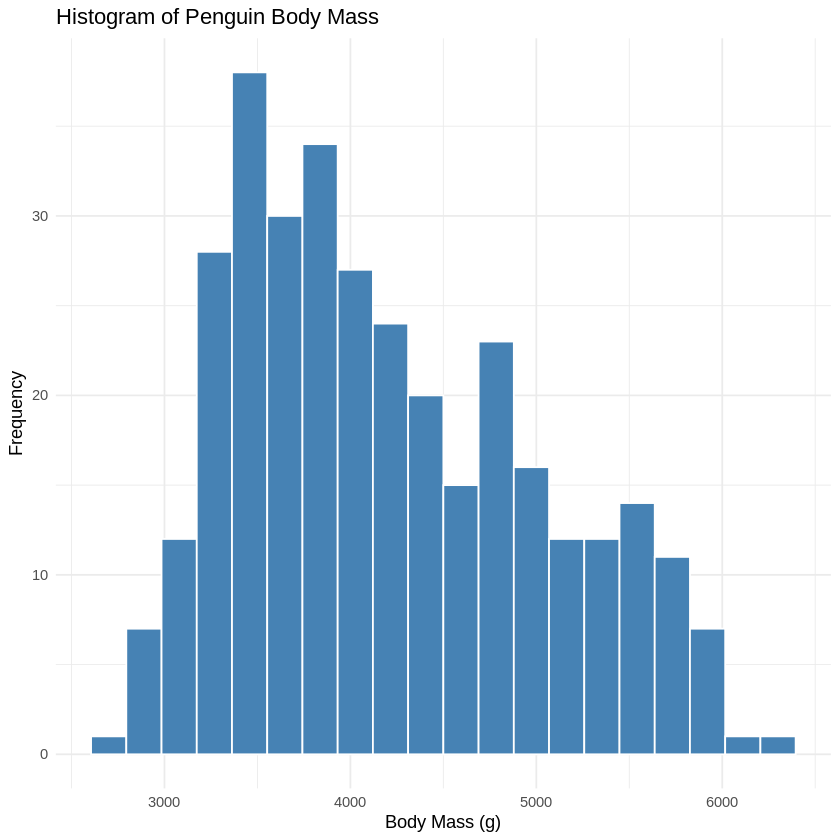

In [ ]:
# Plot the overall body-mass distribution.
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white") +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()


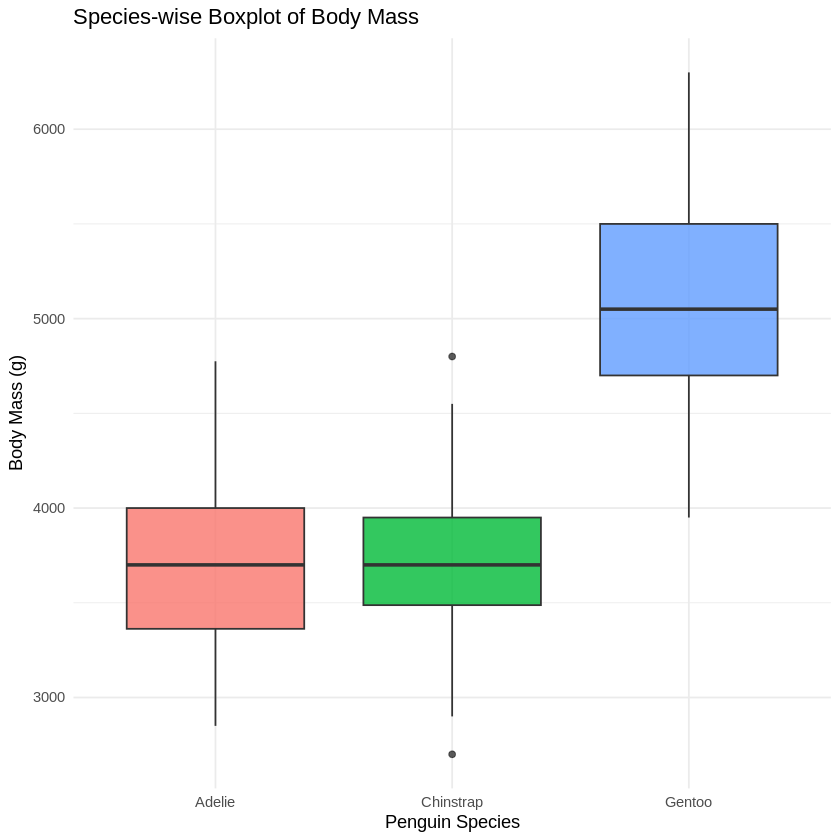

In [ ]:
# Compare body mass across species.
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot(alpha = 0.8) +
  labs(
    title = "Species-wise Boxplot of Body Mass",
    x = "Penguin Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


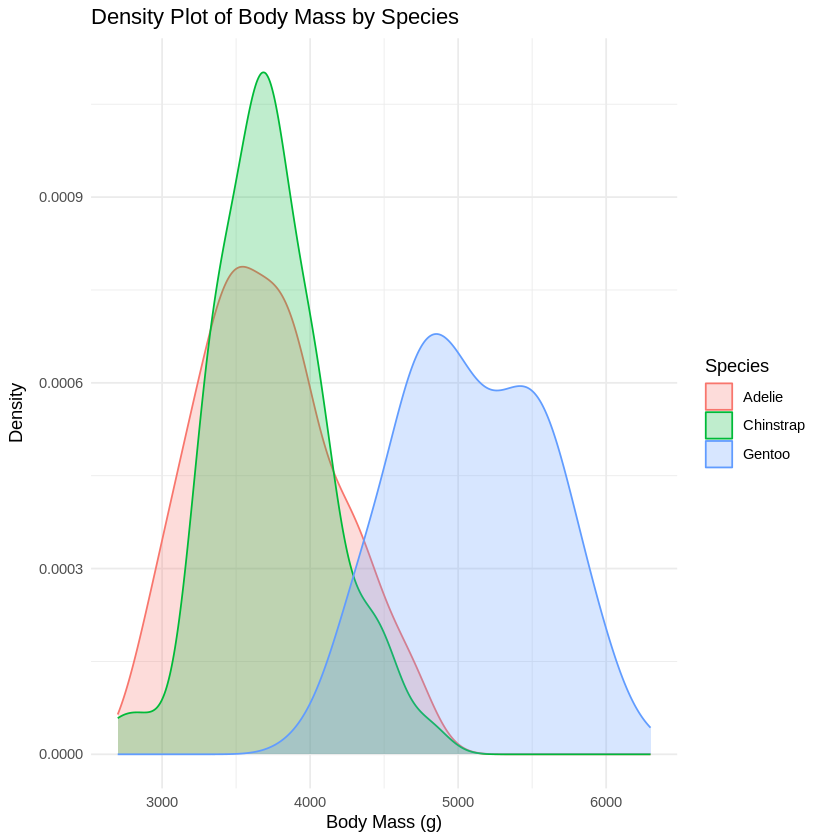

In [ ]:
# Plot density curves by species.
ggplot(penguins_clean, aes(x = body_mass_g, fill = species, color = species)) +
  geom_density(alpha = 0.25) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species",
    color = "Species"
  ) +
  theme_minimal()


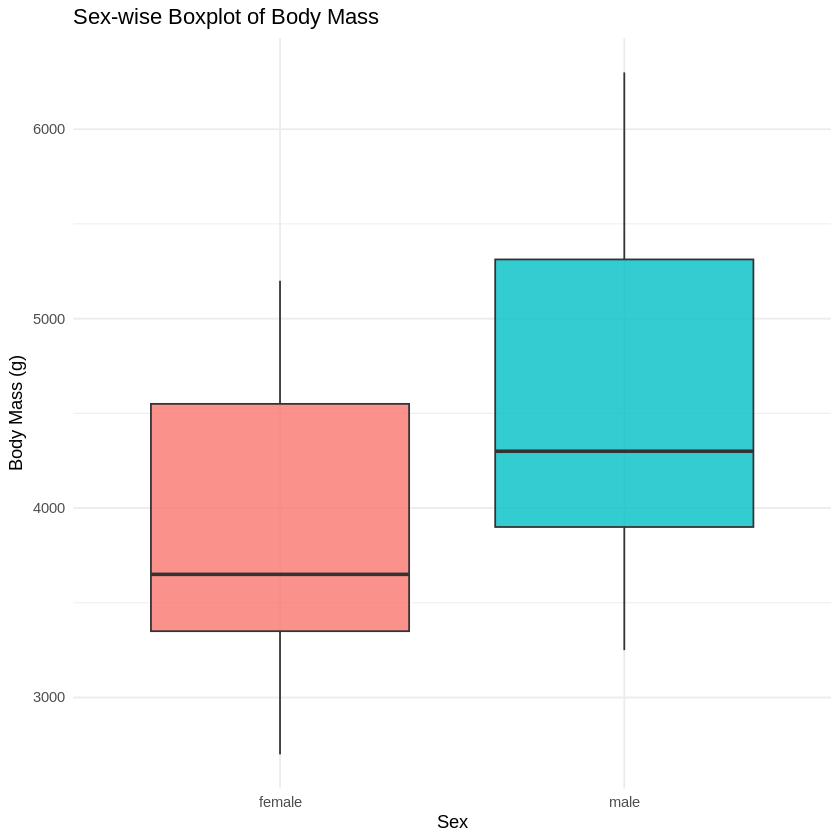

In [ ]:
# Compare body mass across sex.
ggplot(penguins_clean, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot(alpha = 0.8) +
  labs(
    title = "Sex-wise Boxplot of Body Mass",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


## 5. Hypothesis Testing: Male vs Female Body Mass

**Null hypothesis (H₀):** The mean body mass of male penguins equals the mean body mass of female penguins.

**Alternative hypothesis (H₁):** The mean body mass of male penguins differs from the mean body mass of female penguins.

A Shapiro-Wilk test and QQ-plots are used to assess normality before performing an independent two-sample Welch t-test.

In [ ]:
# Check sample sizes by sex.
table(penguins_clean$sex)

# Perform Shapiro-Wilk normality tests.
shapiro_male <- shapiro.test(penguins_clean$body_mass_g[penguins_clean$sex == "male"])
shapiro_female <- shapiro.test(penguins_clean$body_mass_g[penguins_clean$sex == "female"])

shapiro_male
shapiro_female



female   male 
   165    168 


	Shapiro-Wilk normality test

data:  penguins_clean$body_mass_g[penguins_clean$sex == "male"]
W = 0.92504, p-value = 0.0000001227



	Shapiro-Wilk normality test

data:  penguins_clean$body_mass_g[penguins_clean$sex == "female"]
W = 0.91931, p-value = 0.00000006155


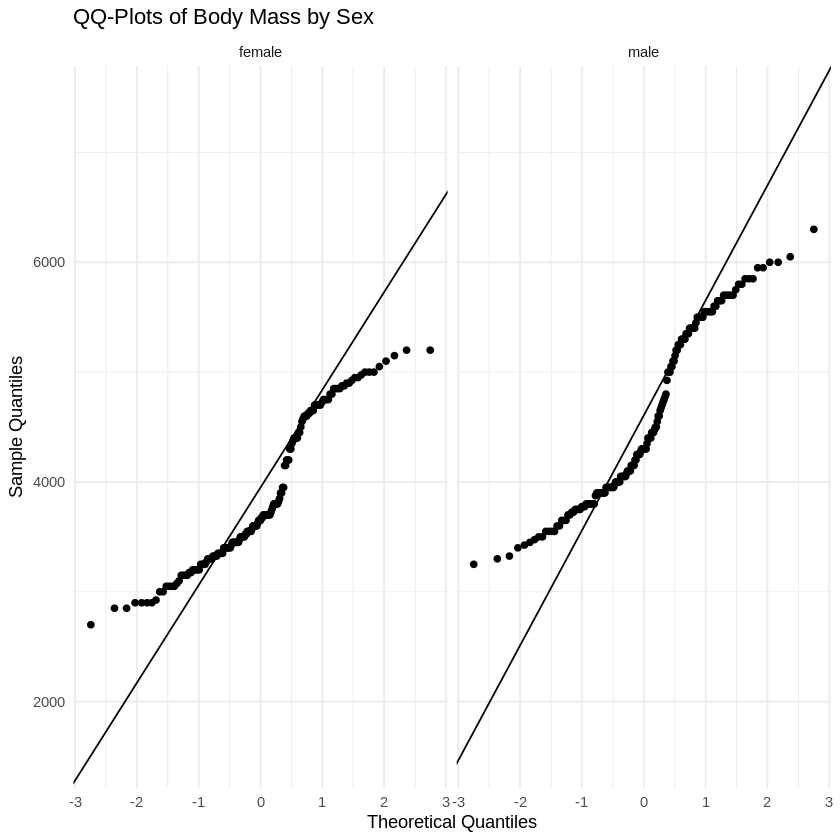

In [ ]:
# Create QQ-plots for body mass by sex.
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~sex) +
  labs(
    title = "QQ-Plots of Body Mass by Sex",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()


In [ ]:
# Perform the independent two-sample Welch t-test.
sex_ttest <- t.test(body_mass_g ~ sex, data = penguins_clean, var.equal = FALSE)

sex_ttest



	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 0.0000000000000004794
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [ ]:
# Calculate Cohen's d effect size.
sex_cohens_d <- cohens_d(body_mass_g ~ sex, data = penguins_clean)

sex_cohens_d


Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


### Interpretation

The t-test output provides the mean difference, 95% confidence interval, t-statistic, degrees of freedom, and p-value. A p-value below 0.05 indicates statistically significant evidence of different mean body masses between males and females. Cohen's d describes the practical magnitude of the difference.

## 6. One-Way ANOVA: Body Mass by Species

**Model:** `body_mass_g ~ species`

**Null hypothesis:** All three species have the same mean body mass.

**Alternative hypothesis:** At least one species has a different mean body mass.

Before ANOVA, the distribution and variance assumptions are checked.

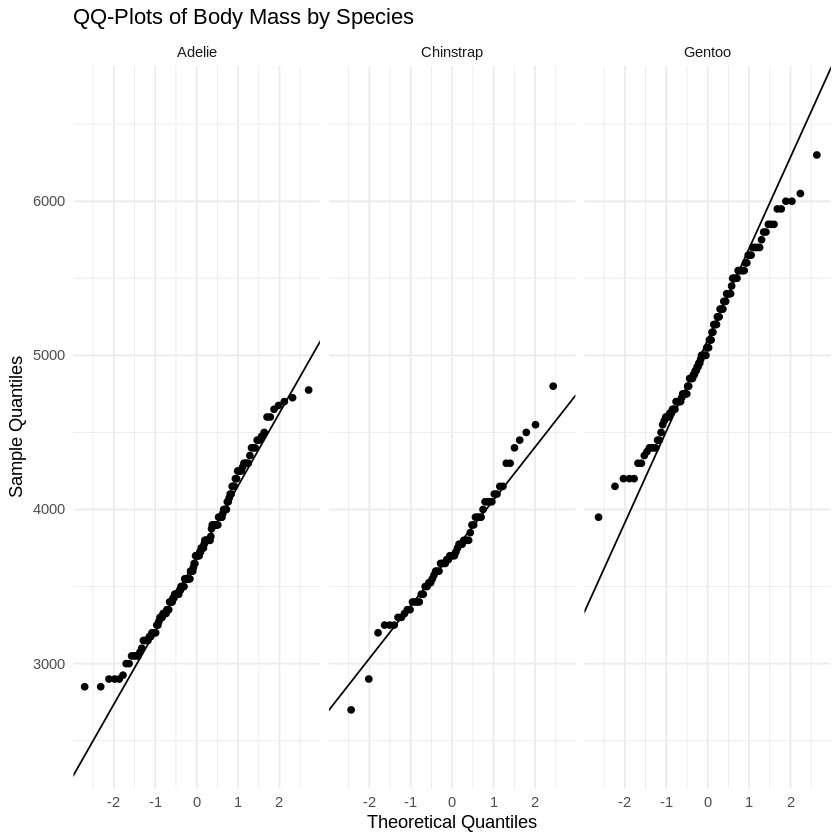

In [ ]:
# Examine body-mass distributions by species.
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(
    title = "QQ-Plots of Body Mass by Species",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()


In [ ]:
# Perform Shapiro-Wilk tests within each species.
species_shapiro <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    W = shapiro.test(body_mass_g)$statistic,
    p_value = shapiro.test(body_mass_g)$p.value,
    .groups = "drop"
  )

species_shapiro


species,W,p_value
<fct>,<dbl>,<dbl>
Adelie,0.9811608,0.0423224
Chinstrap,0.9844938,0.5605082
Gentoo,0.9860612,0.2605247


In [ ]:
# Check homogeneity of variance using Levene's test.
levene_body_mass <- leveneTest(body_mass_g ~ species, data = penguins_clean)

levene_body_mass


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


In [ ]:
# Perform one-way ANOVA.
oneway_anova <- aov(body_mass_g ~ species, data = penguins_clean)

summary(oneway_anova)


             Df    Sum Sq  Mean Sq F value              Pr(>F)    
species       2 145190219 72595110   341.9 <0.0000000000000002 ***
Residuals   330  70069447   212332                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### ANOVA Interpretation

The ANOVA table reports the F-statistic, degrees of freedom, and p-value. If the p-value is below 0.05, the null hypothesis is rejected and there is evidence that mean body mass differs among penguin species.

In [ ]:
# Perform Tukey's HSD when the ANOVA is significant.
tukey_body_mass <- TukeyHSD(oneway_anova)

tukey_body_mass


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


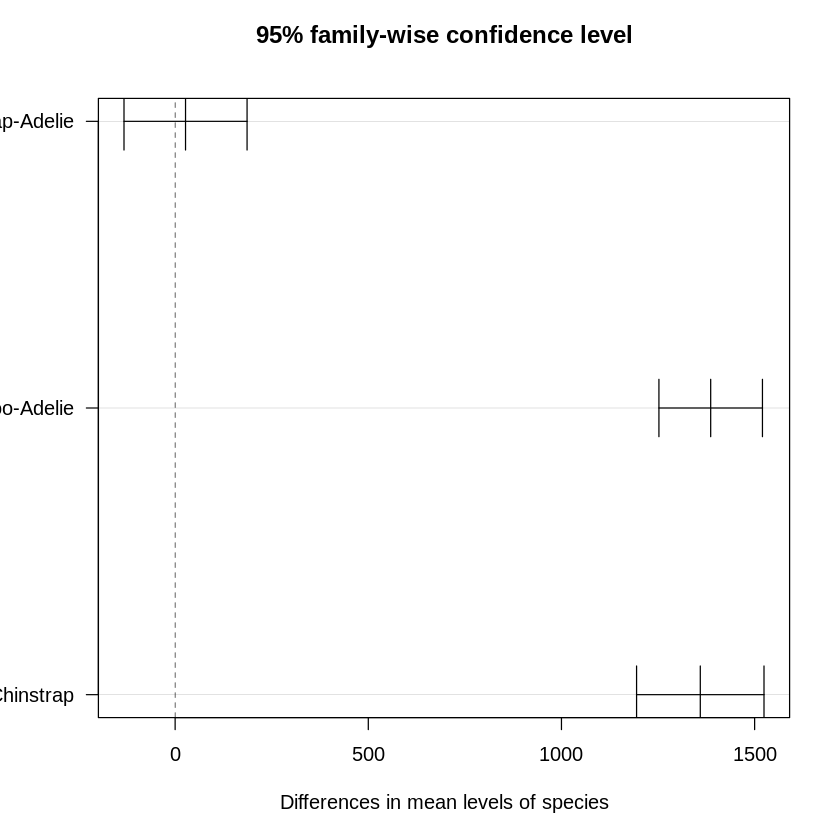

In [ ]:
# Visualize Tukey pairwise differences.
plot(tukey_body_mass, las = 1)


### Tukey Interpretation

Tukey's HSD identifies the specific pairs of species whose mean body masses differ significantly. Pairwise comparisons with adjusted p-values below 0.05 are considered statistically significant.

## 7. Non-Parametric Analysis: Kruskal-Wallis Test

The Kruskal-Wallis test is used as a non-parametric alternative to one-way ANOVA when the ANOVA assumptions are substantially violated.

**Null hypothesis:** The species groups have the same distribution/location.

**Alternative hypothesis:** At least one species differs.

In [ ]:
# Perform the Kruskal-Wallis test.
kruskal_body_mass <- kruskal.test(body_mass_g ~ species, data = penguins_clean)

kruskal_body_mass



	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value <
0.00000000000000022


### Comparison of ANOVA and Kruskal-Wallis

Compare the p-values from the one-way ANOVA and Kruskal-Wallis test. If both tests are significant, they provide consistent evidence that body mass differs among species. The non-parametric test is less dependent on normality assumptions.

In [ ]:
# Display the key p-values side by side.
comparison_tests <- tibble(
  Test = c("One-way ANOVA", "Kruskal-Wallis"),
  P_Value = c(
    summary(oneway_anova)[[1]][["Pr(>F)"]][1],
    kruskal_body_mass$p.value
  )
)

comparison_tests


Test,P_Value
<chr>,<dbl>
One-way ANOVA,0.000000000000000000000000000000000000000000000000000000000000000000000000000000003744505
Kruskal-Wallis,0.000000000000000000000000000000000000000000000088368767442818939552520018605748251174465


## 8. Two-Way ANOVA: Species and Sex

**Model:** `body_mass_g ~ species * sex`

This model evaluates:

1. The main effect of species.
2. The main effect of sex.
3. The species × sex interaction.

The interaction tests whether the effect of sex on body mass depends on penguin species.

In [ ]:
# Perform two-way ANOVA.
twoway_anova <- aov(body_mass_g ~ species * sex, data = penguins_clean)

summary(twoway_anova)


             Df    Sum Sq  Mean Sq F value               Pr(>F)    
species       2 145190219 72595110 758.358 < 0.0000000000000002 ***
sex           1  37090262 37090262 387.460 < 0.0000000000000002 ***
species:sex   2   1676557   838278   8.757             0.000197 ***
Residuals   327  31302628    95727                                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
# Display group means for interpretation.
group_means <- penguins_clean %>%
  group_by(species, sex) %>%
  summarise(
    N = n(),
    Mean_Body_Mass = mean(body_mass_g),
    SD = sd(body_mass_g),
    .groups = "drop"
  )

group_means


species,sex,N,Mean_Body_Mass,SD
<fct>,<fct>,<int>,<dbl>,<dbl>
Adelie,female,73,3368.836,269.3801
Adelie,male,73,4043.493,346.8116
Chinstrap,female,34,3527.206,285.3339
Chinstrap,male,34,3938.971,362.1376
Gentoo,female,58,4679.741,281.5783
Gentoo,male,61,5484.836,313.1586


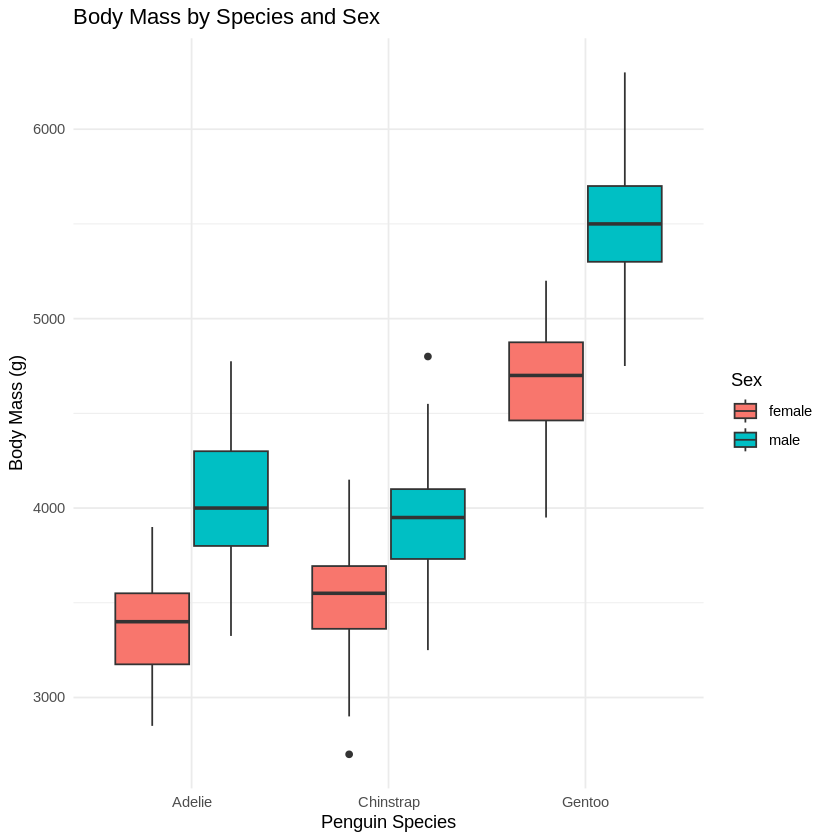

In [ ]:
# Visualize species and sex effects.
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot(position = position_dodge(width = 0.8)) +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Penguin Species",
    y = "Body Mass (g)",
    fill = "Sex"
  ) +
  theme_minimal()


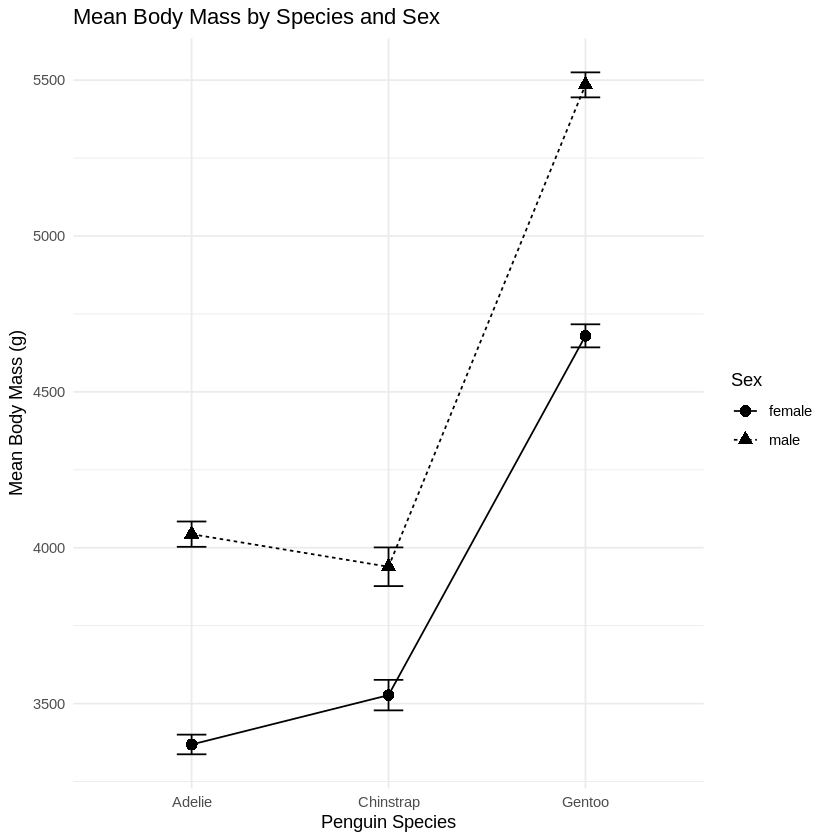

In [ ]:
# Plot group means with standard error.
group_summary <- penguins_clean %>%
  group_by(species, sex) %>%
  summarise(
    Mean = mean(body_mass_g),
    SE = sd(body_mass_g) / sqrt(n()),
    .groups = "drop"
  )

ggplot(group_summary, aes(x = species, y = Mean, group = sex, shape = sex)) +
  geom_point(size = 3) +
  geom_line(aes(linetype = sex)) +
  geom_errorbar(aes(ymin = Mean - SE, ymax = Mean + SE), width = 0.15) +
  labs(
    title = "Mean Body Mass by Species and Sex",
    x = "Penguin Species",
    y = "Mean Body Mass (g)",
    shape = "Sex",
    linetype = "Sex"
  ) +
  theme_minimal()


### Two-Way ANOVA Interpretation

A significant species p-value indicates that body mass varies by species after accounting for sex. A significant sex p-value indicates a difference between male and female body mass after accounting for species. A significant interaction p-value indicates that the sex difference is not the same across all species.

## 9. Additional Analysis: Flipper Length

The one-way ANOVA and Kruskal-Wallis analysis are repeated for **flipper length (`flipper_length_mm`)** to determine whether flipper length varies among species.

In [ ]:
# Calculate species-wise flipper-length statistics.
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    IQR = IQR(flipper_length_mm),
    .groups = "drop"
  )

flipper_stats


species,N,Mean,Median,SD,Minimum,Maximum,IQR
<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Adelie,146,190.1027,190,6.521825,172,210,9.0
Chinstrap,68,195.8235,196,7.131894,178,212,10.0
Gentoo,119,217.2353,216,6.585431,203,231,9.5


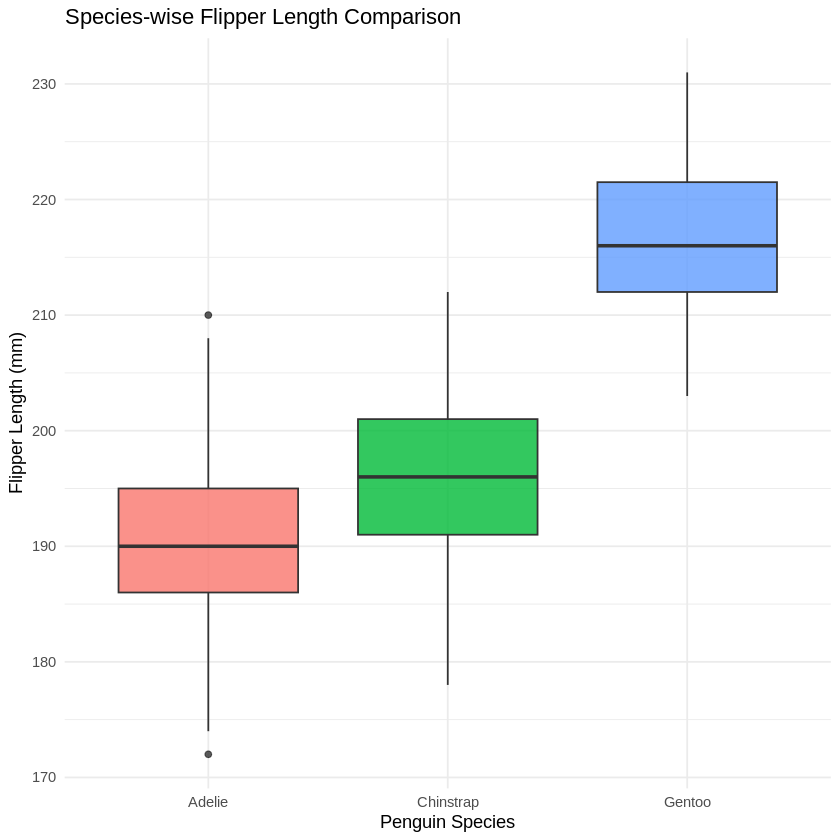

In [ ]:
# Visualize flipper length across species.
ggplot(penguins_clean, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot(alpha = 0.8) +
  labs(
    title = "Species-wise Flipper Length Comparison",
    x = "Penguin Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


In [ ]:
# Check flipper-length normality by species.
flipper_shapiro <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    W = shapiro.test(flipper_length_mm)$statistic,
    p_value = shapiro.test(flipper_length_mm)$p.value,
    .groups = "drop"
  )

flipper_shapiro


species,W,p_value
<fct>,<dbl>,<dbl>
Adelie,0.9934049,0.742742565
Chinstrap,0.9889115,0.810644659
Gentoo,0.9614772,0.001759983


In [ ]:
# Check flipper-length variance homogeneity.
levene_flipper <- leveneTest(flipper_length_mm ~ species, data = penguins_clean)

levene_flipper


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.4427865,0.6426253
,330,NA,NA


In [ ]:
# Perform one-way ANOVA for flipper length.
flipper_anova <- aov(flipper_length_mm ~ species, data = penguins_clean)

summary(flipper_anova)


             Df Sum Sq Mean Sq F value              Pr(>F)    
species       2  50526   25263   567.4 <0.0000000000000002 ***
Residuals   330  14693      45                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
# Perform Tukey HSD for flipper length.
flipper_tukey <- TukeyHSD(flipper_anova)

flipper_tukey


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


In [ ]:
# Perform Kruskal-Wallis test for flipper length.
flipper_kruskal <- kruskal.test(flipper_length_mm ~ species, data = penguins_clean)

flipper_kruskal



	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value <
0.00000000000000022


### Flipper-Length Interpretation

The species-wise boxplot and ANOVA results show whether flipper length differs among species. Tukey's HSD identifies the specific species pairs responsible for significant differences. The Kruskal-Wallis result provides a non-parametric comparison.

## 10. Required QQ-Plots and Group Comparison Visualizations

The following cells provide additional diagnostic and comparison plots required by the problem statement.

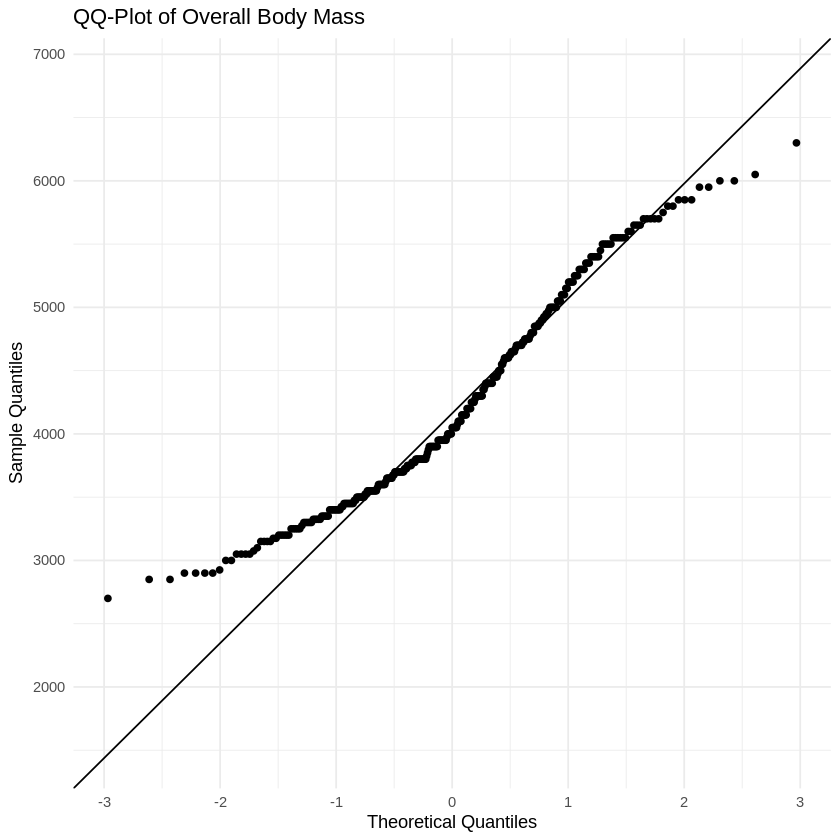

In [ ]:
# QQ-plot for overall body mass.
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  labs(
    title = "QQ-Plot of Overall Body Mass",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()


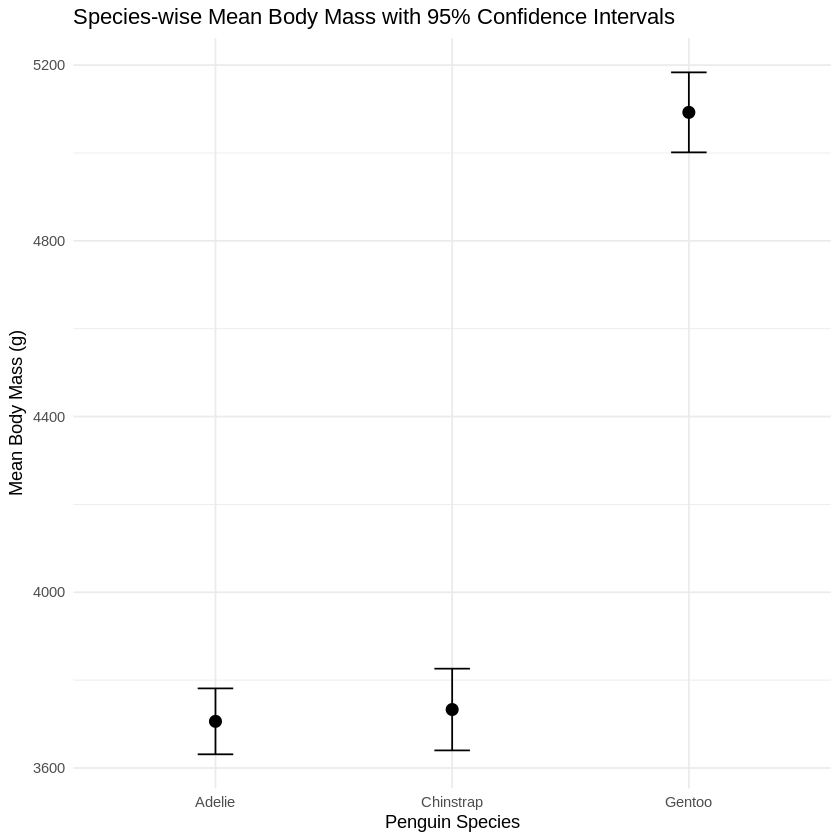

In [ ]:
# Show species-wise body-mass means with confidence intervals.
species_ci <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    SE = sd(body_mass_g) / sqrt(n()),
    CI = qt(0.975, df = n() - 1) * SE,
    .groups = "drop"
  )

ggplot(species_ci, aes(x = species, y = Mean)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = Mean - CI, ymax = Mean + CI), width = 0.15) +
  labs(
    title = "Species-wise Mean Body Mass with 95% Confidence Intervals",
    x = "Penguin Species",
    y = "Mean Body Mass (g)"
  ) +
  theme_minimal()


## 11. Consolidated Results

This section prints the major statistical results in one place for easy reporting.

In [ ]:
# Extract key one-way ANOVA results.
anova_table <- summary(oneway_anova)[[1]]
anova_result <- tibble(
  F_Statistic = anova_table[1, "F value"],
  DF_Between = anova_table[1, "Df"],
  DF_Within = anova_table[2, "Df"],
  P_Value = anova_table[1, "Pr(>F)"]
)

# Extract key t-test results.
ttest_result <- tibble(
  Mean_Female = mean(penguins_clean$body_mass_g[penguins_clean$sex == "female"]),
  Mean_Male = mean(penguins_clean$body_mass_g[penguins_clean$sex == "male"]),
  Mean_Difference = unname(sex_ttest$estimate[1] - sex_ttest$estimate[2]),
  CI_Lower = sex_ttest$conf.int[1],
  CI_Upper = sex_ttest$conf.int[2],
  T_Statistic = unname(sex_ttest$statistic),
  P_Value = sex_ttest$p.value
)

# Print consolidated results.
anova_result
ttest_result
sex_cohens_d
kruskal_body_mass
flipper_stats


F_Statistic,DF_Between,DF_Within,P_Value
<dbl>,<dbl>,<dbl>,<dbl>
341.8949,2,330,0.000000000000000000000000000000000000000000000000000000000000000000000000000000003744505


Mean_Female,Mean_Male,Mean_Difference,CI_Lower,CI_Upper,T_Statistic,P_Value
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3862.273,4545.685,-683.4118,-840.5783,-526.2453,-8.554537,0.0000000000000004793891


Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225



	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value <
0.00000000000000022


species,N,Mean,Median,SD,Minimum,Maximum,IQR
<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Adelie,146,190.1027,190,6.521825,172,210,9.0
Chinstrap,68,195.8235,196,7.131894,178,212,10.0
Gentoo,119,217.2353,216,6.585431,203,231,9.5
